# QuantumCircuits API 教程

QuantumCircuits 是全栈量子软件的**中间表示（IR）层**：从算法线路到 QEC 综合征线路
再到 QCCD 编译产物，共用这一种表示。本教程逐步展示核心 API 的用法。

**全局约定**

- 比特索引 **1-based**（与 Julia 惯例一致）；与 QASM 的 0-based 索引由 IO 层自动换算
- 比特排序为**小端序**：qubit 1 = 矩阵的最低有效位（LSB）
- 多比特门：比特列表的**首比特是矩阵的最高位**（Qiskit 约定）
- IR **无执行语义**：本包不模拟量子态，模拟入口由下游后端实现

In [1]:
using QuantumCircuits

## 1. 比特与寄存器

`QReg` / `CReg` 是量子 / 经典寄存器。寄存器下标 1-based，取出的元素是
0-based 的比特编号（`Qubit`）或经典位引用（`ClbitRef`）。

In [2]:
q = QReg(:q, 4)             # 4 个量子比特，编号 1..4
println("q[1]   = ", q[1])      # 下标即比特编号 → Qubit(1)
println("q[1:2] = ", q[1:2])

c = CReg(:c, 2)             # 2 个经典比特
println("c[1]   = ", c[1])      # ClbitRef
println("length(c) = ", length(c))

q[1]   = q[1]
q[1:2] = Qubit[q[1], q[2]]
c[1]   = c[1]
length(c) = 2


## 2. 门库：常数门与参数门

`Gate` 是**不携带比特位置**的数学对象（Cirq 模式）。`mat` 给出门矩阵；
元素类型参数化——实数门给出实矩阵、复数门给出复矩阵。

In [3]:
using LinearAlgebra

println("H  = ", mat(H))
println("CX = ", mat(CX))
println("mat(X) 的元素类型：", eltype(mat(X)))     # 实数门 → Float64
println("mat(Y) 的元素类型：", eltype(mat(Y)))     # 复数门 → ComplexF64
println("nqubits(CCX) = ", nqubits(CCX), ",  num_params(RX) = ", num_params(RX))

H  = [0.7071067811865475 0.7071067811865475; 0.7071067811865475 -0.7071067811865475]
CX = [1.0 0.0 0.0 0.0; 0.0 1.0 0.0 0.0; 0.0 0.0 0.0 1.0; 0.0 0.0 1.0 0.0]
mat(X) 的元素类型：Float64
mat(Y) 的元素类型：ComplexF64
nqubits(CCX) = 3,  num_params(RX) = 1


**门调用即定位**：把门作用于比特，得到 `Operation`。参数门接受 `Real`、
`Param` 或 `Symbol`（符号参数用于变分工作流的延迟绑定）。

In [4]:
println(H(1))          # H 作用在 qubit 1
println(CX(1, 2))      # 控制 1、目标 2（首比特 = 矩阵最高位）
println(RX(π / 4, 3))  # 数值参数
println(RX(:θ, 3))     # 符号参数：先建线路，后绑参

Hq[1]
CXq[1], q[2]
RX(0.7853981633974483)q[3]
RX(:θ)q[3]


## 3. 修饰符：inv / pow / ctrl / negctrl

四个惰性包装，可作用在 `Gate` 或 `GateOp` 上；`ctrl` 把控制位放在比特列表最前。

In [5]:
println("mat(pow(H, 2)) ≈ I：              ", mat(pow(H, 2)) ≈ mat(ID))
println("inv(RX(0.3)) ≈ RX(-0.3)：          ", mat(inv(RX(0.3, 1))) ≈ mat(RX(-0.3, 1)))
println("ctrl(H(1), 2) 比特顺序（控制位前置）：", qubits(ctrl(H(1), 2)), "  → 等价 CH")
println("negctrl(H(3), 1, 2) 矩阵尺寸：     ", size(mat(negctrl(H(3), 1, 2))))

mat(pow(H, 2)) ≈ I：              true
inv(RX(0.3)) ≈ RX(-0.3)：          true
ctrl(H(1), 2) 比特顺序（控制位前置）：[2, 1]  → 等价 CH
negctrl(H(3), 1, 2) 矩阵尺寸：     (8, 8)


## 4. 线路构建

线路是 `Operation` 的序列，默认自带 `QReg(:q, n)` 与 `CReg(:c, n)`。
`push!` / `<<`（追加）与 `*`（纯函数拼接）都可用。

In [6]:
bell = Circuit(2)
push!(bell, H(1))
push!(bell, CX(1, 2))          # 亦可：bell << CX(1, 2)

println("num_ops     = ", num_ops(bell))
println("depth       = ", depth(bell))
println("count_ops   = ", count_ops(bell))
println("qubits_used = ", qubits_used(bell))
println("validate    = ", validate(bell) === bell)

num_ops     = 2
depth       = 2
count_ops   = Dict(:H => 1, :CX => 1)
qubits_used = [1, 2]
validate    = true


测量、重置（`reinit` → `ReinitOp`，把比特复位到 |0⟩）与屏障都是一等操作：

In [7]:
push!(bell, measure([1, 2], bell.cregs[1][1:2]))   # q1,q2 → c[1],c[2]
println(draw(bell))

q[1]: ─H──●──M─
          │  │ 
q[2]: ────X──M─
             │ 
c[1]: ═══════╡═
             │ 
c[2]: ═══════╡═



## 5. 经典控制

经典寄存器可与整数比较生成 `Cond`，`if_then` 把条件分支写进 IR：

In [8]:
c = Circuit(2)
push!(c, H(1))
push!(c, measure(1, c.cregs[1][1]))
if_then(c, c.cregs[1][1] == 1, Circuit([X(2)]))    # 若 c[1]==1 则 X q2
println(draw(c))

             if (c == 1)    
q[1]: ─H──M─────────────────
          │                 
q[2]: ───────────IF───────X─
          │       │         
c[1]: ════╡═════════════════
                  │         
c[2]: ══════════════════════



## 6. 参数化线路与绑参

变分工作流：先用 `Symbol` / `Param` 建线路，之后 `assign` 一次性绑定。
`parameters` 返回去重、按出现顺序排列的参数表。

In [9]:
vqe = Circuit(4)
φ = params(:φ, 3)                 # 批量参数 φ[1..3]
for q in 1:4
    push!(vqe, RX(:θ, q))         # 权重共享的旋转层
end
for q in 1:3
    push!(vqe, RZZ(φ[q], q, q + 1))   # 纠缠层
end

println("自由参数：", parameters(vqe))

bound = assign(vqe, Dict(:θ => 0.3, φ => [π/4, 0.5, 0.2]))   # 纯函数，不改原线路
println("绑参后剩余参数：", parameters(bound))
println("validate：", validate(bound) === bound)

自由参数：Param[:θ, :φ[1], :φ[2], :φ[3]]
绑参后剩余参数：Param[]
validate：true


## 7. 复合结构：UserGate 与 block

- `UserGate`：自定义门（显式矩阵，或用子线路定义、延迟分解）
- `block`：命名 / 重复的子线路块，`unroll` 展开为基本操作

In [10]:
# 子线路定义的门
def = Circuit([H(1), CX(1, 2)])
bell_gate = UserGate(:bell, 2, def)
println("bell_gate 矩阵是否酉：", mat(bell_gate)' * mat(bell_gate) ≈ Matrix(1.0I, 4, 4))

# 命名块 + 重复
rnd = block(Circuit([H(1), CX(1, 2)]); name=:round, repeat=2)
fl = unroll(rnd)
println("unroll(:round ×2) 展开出 ", length(fl), " 个基本操作：")
foreach(println, fl)

bell_gate 矩阵是否酉：true
unroll(:round ×2) 展开出 4 个基本操作：
Hq[1]
CXq[1], q[2]
Hq[1]
CXq[1], q[2]


## 8. 依赖 DAG

`dag` 把线路转成依赖图：量子比特上的先后顺序、测量到条件分支的经典依赖都会成为边，
供并行调度 / 优化使用。

In [11]:
cdag = Circuit(3)
push!(cdag, H(1))        # 操作 1
push!(cdag, CX(1, 2))    # 操作 2：依赖 1
push!(cdag, X(2))        # 操作 3：依赖 2
push!(cdag, X(3))        # 操作 4：独立

d = dag(cdag)
println("节点数 = ", length(nodes(d)))
println("操作 2 依赖：", dependencies(d, 2))
println("操作 4 依赖：", dependencies(d, 4), "   ← 与操作 1 并行")

节点数 = 4
操作 2 依赖：[1]
操作 4 依赖：[3]   ← 与操作 1 并行


## 9. Hamiltonian 子模块

Pauli 串代数（乘法、加法合并同类项、伴随）+ 稠密矩阵展开（小端序）。

In [12]:
using QuantumCircuits.Hamiltonian

println("X·Y = ", PauliTerm(1.0, 1=>:X) * PauliTerm(1.0, 1=>:Y))

h = PauliSum([PauliTerm(1.0, 1=>:Z, 2=>:Z),      # Z⊗Z
              PauliTerm(0.5, 1=>:X)])            # 0.5·X⊗I
m = mat(h, 2)                                     # 2 比特稠密矩阵
println("mat(h, 2)：size = ", size(m), ",  eltype = ", eltype(m))

X·Y = 0.0 + 1.0im * Z(1)
mat(h, 2)：size = (4, 4),  eltype = Float64


## 10. QASM 导入 / 导出

`to_qasm`（`version=2` 或 `3`）、`read_qasm` 读回，`write_qasm` 直接落盘。

In [13]:
qasm2 = to_qasm(bell; version=2)
println(qasm2)

back = read_qasm(qasm2)
println("读回操作数 = ", num_ops(back))
println("――― QASM3（绑参线路）―――")
println(to_qasm(bound; version=3))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];

读回操作数 = 4
――― QASM3（绑参线路）―――
OPENQASM 3.0;
include "stdgates.inc";
gate rzz(theta) a, b { cx a, b; rz(theta) b; cx a, b; }

qubit[4] q;
bit[4] c;
rx(0.3) q[0];
rx(0.3) q[1];
rx(0.3) q[2];
rx(0.3) q[3];
rzz(0.7853981633974483) q[0], q[1];
rzz(0.5) q[1], q[2];
rzz(0.2) q[2], q[3];



## 11. 可视化：文本图

`draw` 生成文本线路图（REPL 中 `show` 线路即调用它）；`ascii=true` 走纯 ASCII 字符。

In [14]:
demo = Circuit(3)
push!(demo, H(1))
push!(demo, CX(1, 2))
push!(demo, RZZ(0.7, 1, 2))
push!(demo, SWAP(1, 2))
push!(demo, barrier(1, 2, 3))
push!(demo, reinit(3))
push!(demo, measure(1, demo.cregs[1][1]))
println(draw(demo))
println("――― ASCII 模式 ―――")
println(draw(demo; ascii=true))

             RZZ(0.7)               
q[1]: ─H──●─────●──────✕──░───────M─
          │     │      │  │       │ 
q[2]: ────X─────●──────✕──░─────────
                          │       │ 
q[3]: ────────────────────░──|0>────
                                  │ 
c[1]: ════════════════════════════╡═
c[2]: ══════════════════════════════
c[3]: ══════════════════════════════

――― ASCII 模式 ―――
             RZZ(0.7)               
q[1]: -H--*-----*------x--#-------M-
          |     |      |  |       | 
q[2]: ----X-----*------x--#---------
                          |       | 
q[3]: --------------------#--|0>----
                                  | 
c[1]: ============================>=
c[2]: ==============================
c[3]: ==============================



## 12. 图形渲染（Luxor 包扩展）

安装 Luxor 后，包扩展 `QuantumCircuitsLuxorExt` 自动加载：`plot(c)` 返回 SVG 字符串，
`save_plot(c, "file.svg")` 按扩展名保存 `svg` / `png` / `pdf`。
通过 `Base.get_extension(QuantumCircuits, :QuantumCircuitsLuxorExt)` 拿到扩展模块。

下面定义一个小工具，把 `plot(c; format=:png)` 的字节流转成 data-URI 内嵌显示——
PNG 在各类查看器中渲染一致；需要矢量图时用 `save_plot` 存 SVG / PDF。

In [15]:
using Luxor, Base64
const QCExt = Base.get_extension(QuantumCircuits, :QuantumCircuitsLuxorExt)
QCExt === nothing && error("Luxor 扩展未加载，请先 using Pkg; Pkg.add(\"Luxor\")")
println("扩展已加载：", nameof(QCExt))

"把线路渲染为内嵌 PNG（data URI），各查看器渲染一致"
png_inline(c; kwargs...) =
    HTML("<img src=\"data:image/png;base64,$(base64encode(QCExt.plot(c; format=:png, kwargs...)))\" />")

扩展已加载：QuantumCircuitsLuxorExt



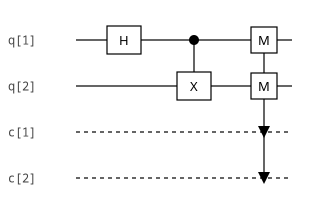

In [16]:
png_inline(bell)    # Bell 态制备 + 测量（含经典线）


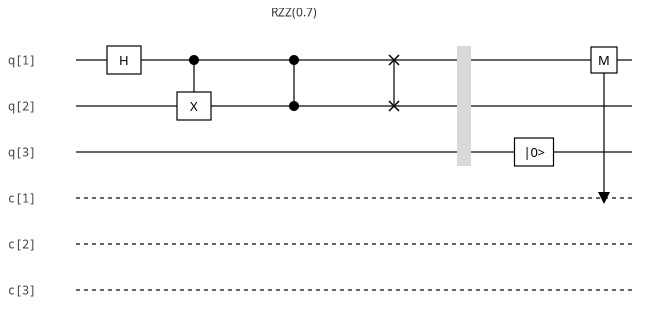

In [17]:
png_inline(demo)    # SWAP 交叉 / 屏障 / reinit / 测量


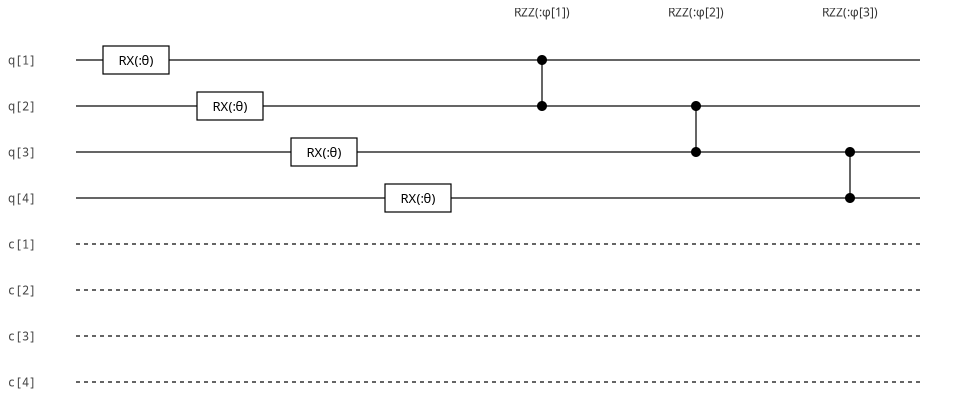

In [18]:
png_inline(vqe)     # 参数化线路：标签显示参数名

In [19]:
QCExt.save_plot(demo, "circuit_demo.svg")
QCExt.save_plot(demo, "circuit_demo.png")
println("已保存 circuit_demo.svg / circuit_demo.png")

已保存 circuit_demo.svg / circuit_demo.png


## 下一步

- 文档首页：`docs/src/index.md`（含比特排序 / 张量转换公式的完整说明）
- API 参考：`docs/src/api.md`
- 扩展指南（下游如何接入模拟器后端）：`docs/src/extending.md`
- QASM 读写细节：`docs/src/io.md`